Using device: cuda
NIH path:    /kaggle/input/datasets/shahriar26s/malaria-detection
Lacuna path: /kaggle/input/datasets/rajsahu2004/lacuna-malaria-detection-dataset

Split directories:
  Train: /kaggle/input/datasets/shahriar26s/malaria-detection/Malaria Dataset/train
  Valid: /kaggle/input/datasets/shahriar26s/malaria-detection/Malaria Dataset/valid
  Test:  /kaggle/input/datasets/shahriar26s/malaria-detection/Malaria Dataset/test

Loading Train:
  'Uninfected' → label 0: 6582 images
  'Parasitized' → label 1: 6570 images
  Total: 13152 images | Parasitized: 6570 | Uninfected: 6582

Loading Valid:
  'Uninfected' → label 0: 624 images
  'Parasitized' → label 1: 629 images
  Total: 1253 images | Parasitized: 629 | Uninfected: 624

Loading Test:
  'Uninfected' → label 0: 317 images
  'Parasitized' → label 1: 309 images
  Total: 626 images | Parasitized: 309 | Uninfected: 317

Batches — Train: 206 | Val: 20 | Test: 10

Sanity check — first batch:
  Image shape: torch.Size([64, 3, 224, 22

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


ViT-B/16  |  Total: 85,800,194  |  Trainable: 85,800,194

STAGE 1: Training source domain model on NIH clean malaria data

Epoch 1/10  (LR: 2.00e-05)
----------------------------------------
    Batch 100/206 | Loss: 0.0180
    Batch 200/206 | Loss: 0.1032
  Train → Loss: 0.1463 | Acc: 0.9529
  Val   → Loss: 0.1321  | Acc: 0.9593 | F1: 0.9604 | AUC: 0.9941
  ✓ Best model saved

Epoch 2/10  (LR: 1.95e-05)
----------------------------------------
    Batch 100/206 | Loss: 0.0906
    Batch 200/206 | Loss: 0.1155
  Train → Loss: 0.0940 | Acc: 0.9673
  Val   → Loss: 0.1029  | Acc: 0.9649 | F1: 0.9645 | AUC: 0.9951
  ✓ Best model saved

Epoch 3/10  (LR: 1.81e-05)
----------------------------------------
    Batch 100/206 | Loss: 0.0294
    Batch 200/206 | Loss: 0.1043
  Train → Loss: 0.0739 | Acc: 0.9764
  Val   → Loss: 0.0998  | Acc: 0.9665 | F1: 0.9665 | AUC: 0.9942

Epoch 4/10  (LR: 1.59e-05)
----------------------------------------
    Batch 100/206 | Loss: 0.0017
    Batch 200/206 | Lo

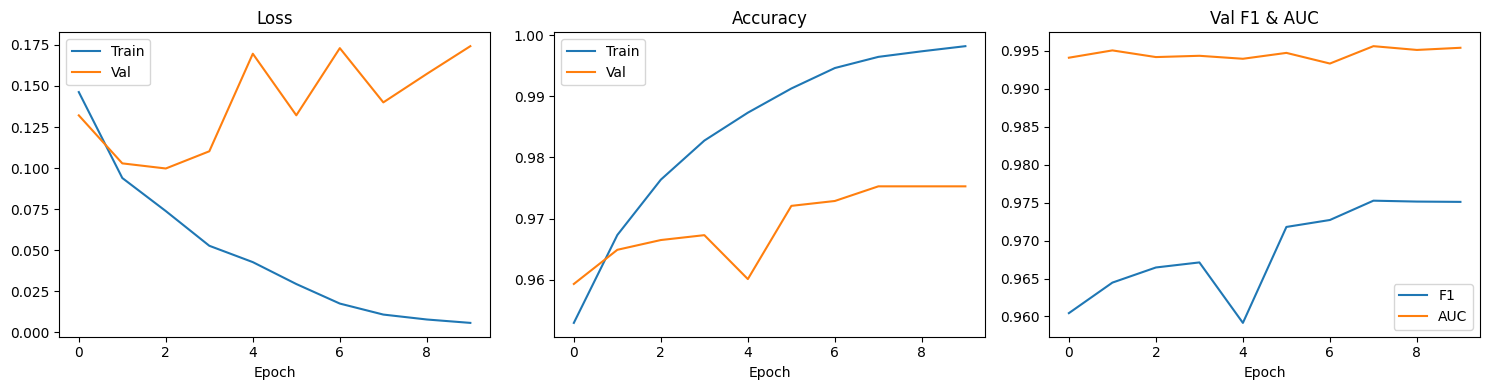


STAGE 1 COMPLETE
Files saved to /kaggle/working/:
  source_domain_model_best.pth
  source_domain_model_final.pth  ← use this in Stage 2
  stage1_training_curves.png


In [1]:
# =============================================================================
# STAGE 1 (FIXED): Source Domain Model Training
# Domain-Shift-Aware LoRA for Malaria Detection in LMIC Settings
# =============================================================================

# ── 0. IMPORTS ────────────────────────────────────────────────────────────────

import os, random
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

# ── 1. REPRODUCIBILITY + GPU CHECK ───────────────────────────────────────────

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

if str(DEVICE) == "cpu":
    raise RuntimeError(
        "No GPU detected. "
        "Go to Kaggle → Session options → Accelerator → GPU T4 x2"
    )

# ── 2. DATA PATHS ─────────────────────────────────────────────────────────────

import kagglehub
nih_path    = kagglehub.dataset_download("shahriar26s/malaria-detection")
lacuna_path = kagglehub.dataset_download("rajsahu2004/lacuna-malaria-detection-dataset")
print(f"NIH path:    {nih_path}")
print(f"Lacuna path: {lacuna_path}")

# ── 3. DATASET CLASS (FIXED) ──────────────────────────────────────────────────

class MalariaDataset(Dataset):
    """
    FIX: Uses explicit class map instead of auto-detection.
    Always assigns Parasitized=1, Uninfected=0 regardless of folder casing.
    Also validates that BOTH classes are present before returning.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir  = Path(root_dir)
        self.transform = transform
        self.samples   = []

        valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

        # Explicit mapping — handles any capitalisation
        for folder in self.root_dir.iterdir():
            if not folder.is_dir():
                continue
            name_lower = folder.name.lower()

            if 'parasit' in name_lower:
                label = 1
            elif 'uninfect' in name_lower or 'normal' in name_lower:
                label = 0
            else:
                print(f"  WARNING: Unrecognised folder '{folder.name}' — skipping")
                continue

            count = 0
            for img_path in folder.iterdir():
                if img_path.suffix.lower() in valid_ext:
                    self.samples.append((str(img_path), label))
                    count += 1
            print(f"  '{folder.name}' → label {label}: {count} images")

        # ── CRITICAL CHECK: both classes must be present ──
        labels_present = set(s[1] for s in self.samples)
        if labels_present != {0, 1}:
            raise ValueError(
                f"Dataset at {root_dir} only contains classes: {labels_present}. "
                f"Expected both 0 (Uninfected) and 1 (Parasitized). "
                f"Check folder names: {[d.name for d in self.root_dir.iterdir() if d.is_dir()]}"
            )

        print(f"  Total: {len(self.samples)} images | "
              f"Parasitized: {sum(1 for s in self.samples if s[1]==1)} | "
              f"Uninfected: {sum(1 for s in self.samples if s[1]==0)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# ── 4. TRANSFORMS ─────────────────────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── 5. FIND SPLIT DIRECTORIES ─────────────────────────────────────────────────

def find_split_dir(base_path, split_name):
    """Search recursively for a split folder that contains class subfolders."""
    for p in Path(base_path).rglob('*'):
        if p.is_dir() and p.name.lower() == split_name.lower():
            subdirs = [d for d in p.iterdir() if d.is_dir()]
            if len(subdirs) >= 2:
                return p
    return None

train_dir = find_split_dir(nih_path, 'train')
val_dir   = find_split_dir(nih_path, 'valid')
test_dir  = find_split_dir(nih_path, 'test')

print(f"\nSplit directories:")
print(f"  Train: {train_dir}")
print(f"  Valid: {val_dir}")
print(f"  Test:  {test_dir}")

# Safety check
for name, d in [('train', train_dir), ('valid', val_dir), ('test', test_dir)]:
    if d is None:
        raise FileNotFoundError(
            f"Could not find '{name}' folder under {nih_path}. "
            f"Run os.walk(nih_path) to inspect the structure."
        )

# ── 6. LOAD DATASETS ──────────────────────────────────────────────────────────

print("\nLoading Train:")
train_dataset = MalariaDataset(train_dir, transform=train_transform)

print("\nLoading Valid:")
val_dataset = MalariaDataset(val_dir, transform=val_transform)

print("\nLoading Test:")
test_dataset = MalariaDataset(test_dir, transform=val_transform)

# ── 7. DATALOADERS ────────────────────────────────────────────────────────────

BATCH_SIZE  = 64
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nBatches — Train: {len(train_loader)} | "
      f"Val: {len(val_loader)} | Test: {len(test_loader)}")

# ── QUICK SANITY CHECK: verify both classes appear in first batch ─────────────
images_chk, labels_chk = next(iter(train_loader))
print(f"\nSanity check — first batch:")
print(f"  Image shape: {images_chk.shape}")
print(f"  Labels in batch: {labels_chk.unique().tolist()}  ← must contain 0 AND 1")

if not (0 in labels_chk and 1 in labels_chk):
    print("  WARNING: first batch has only one class — "
          "check dataset loading above before proceeding")
else:
    print("  ✓ Both classes present")

# ── 8. MODEL ──────────────────────────────────────────────────────────────────

model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nViT-B/16  |  Total: {total_params:,}  |  Trainable: {trainable_params:,}")

# ── 9. TRAINING SETUP ─────────────────────────────────────────────────────────

EPOCHS        = 10          # reduced from 20 — enough to get a strong source model
LEARNING_RATE = 2e-5
WEIGHT_DECAY  = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

# ── 10. TRAIN / EVAL FUNCTIONS ────────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for i, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if (i + 1) % 100 == 0:
            print(f"    Batch {i+1}/{len(loader)} | Loss: {loss.item():.4f}")

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item()

            probs = torch.softmax(outputs, 1)[:, 1].cpu().numpy()
            preds = torch.argmax(outputs, 1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    # FIX: guard against single-class batches
    classes_present = set(all_labels)
    if len(classes_present) < 2:
        print(f"  WARNING: evaluation set contains only class(es) {classes_present} "
              f"— AUC cannot be computed. Check dataset loading.")
        auc = float('nan')
    else:
        auc = roc_auc_score(all_labels, all_probs)

    return (total_loss / len(loader),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='binary'),
            auc)

# ── 11. TRAINING LOOP ─────────────────────────────────────────────────────────

print("\n" + "="*60)
print("STAGE 1: Training source domain model on NIH clean malaria data")
print("="*60)

history = {k: [] for k in
           ['train_loss','train_acc','val_loss','val_acc','val_f1','val_auc']}

best_val_auc    = 0.0
best_epoch      = 0
OUTPUT_DIR      = '/kaggle/working/'
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, 'source_domain_model_best.pth')

for epoch in range(1, EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch {epoch}/{EPOCHS}  (LR: {current_lr:.2e})")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_f1, val_auc = evaluate(
        model, val_loader, criterion, DEVICE)
    scheduler.step()

    for k, v in zip(history.keys(),
                    [train_loss, train_acc, val_loss, val_acc, val_f1, val_auc]):
        history[k].append(v)

    print(f"  Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f}  | Acc: {val_acc:.4f} | "
          f"F1: {val_f1:.4f} | AUC: {val_auc:.4f}")

    # Save best model — uses F1 as fallback if AUC is nan
    save_metric = val_auc if not np.isnan(val_auc) else val_f1
    if save_metric > best_val_auc:
        best_val_auc = save_metric
        best_epoch   = epoch
        torch.save({
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_auc':         val_auc,
            'val_f1':          val_f1,
            'val_acc':         val_acc,
        }, BEST_MODEL_PATH)
        print(f"  ✓ Best model saved")

# FIX: always save final model regardless of whether best was saved
FINAL_MODEL_PATH = os.path.join(OUTPUT_DIR, 'source_domain_model_final.pth')
torch.save({
    'model_state':  model.state_dict(),
    'model_config': 'vit_base_patch16_224',
    'num_classes':  2,
}, FINAL_MODEL_PATH)
print(f"\nFinal model always saved to: {FINAL_MODEL_PATH}")

print(f"\nBest checkpoint: Epoch {best_epoch} | Metric: {best_val_auc:.4f}")

# ── 12. FINAL TEST EVALUATION ─────────────────────────────────────────────────

print("\n" + "="*60)
print("Final evaluation on NIH test set")
print("="*60)

# FIX: load best model only if it exists, else use current model
if os.path.exists(BEST_MODEL_PATH):
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state'])
    print("Loaded best checkpoint for test evaluation")
else:
    print("No best checkpoint found — evaluating current model state")

test_loss, test_acc, test_f1, test_auc = evaluate(
    model, test_loader, criterion, DEVICE)

print(f"\nTest Results — Source Domain (NIH Clean Malaria):")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  F1 Score : {test_f1:.4f}")
print(f"  AUC-ROC  : {test_auc:.4f}")
print(f"\n  → These numbers go in Table 1 of your paper")
print(f"    as 'Source Domain Performance'")

# ── 13. TRAINING CURVES ───────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['val_f1'],  label='F1')
axes[2].plot(history['val_auc'], label='AUC')
axes[2].set_title('Val F1 & AUC'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage1_training_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("STAGE 1 COMPLETE")
print("="*60)
print(f"Files saved to {OUTPUT_DIR}:")
print(f"  source_domain_model_best.pth")
print(f"  source_domain_model_final.pth  ← use this in Stage 2")
print(f"  stage1_training_curves.png")